<a href="https://colab.research.google.com/github/Bhattkiral/Stock-data-analysis/blob/main/Netflix_python_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/Netflix data.csv', encoding='latin1')
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Preprocessing and Cleaning

Before creating the visualizations, let's preprocess and clean the dataset. This includes checking for missing values, converting data types, and extracting new features that can be useful for our dashboard.

In [ ]:
# Display basic information about the DataFrame to identify missing values and data types
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

From the info above, we can see several columns with missing values. Let's address these and convert the `date_added` column to a datetime object.

In [ ]:
# Fill missing 'director' values with 'Unknown'
df['director'] = df['director'].fillna('Unknown')

# Fill missing 'cast' values with 'No Cast'
df['cast'] = df['cast'].fillna('No Cast')

# Fill missing 'country' values with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# Drop rows where 'date_added' or 'rating' are missing, as these are crucial for analysis
df.dropna(subset=['date_added', 'rating'], inplace=True)

# Convert 'date_added' to datetime objects with mixed format inference, coercing errors
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

# Drop rows where 'date_added' is NaT after coercion, as these could not be parsed
df.dropna(subset=['date_added'], inplace=True)

# Extract year and month added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Cast,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,No Cast,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September


Now that the data is cleaner, let's calculate some Key Performance Indicators (KPIs) to start our dashboard.

In [ ]:
# KPI: Total number of titles
total_titles = len(df)
print(f"Total Number of Titles: {total_titles}")

# KPI: Number of Movies and TV Shows
content_type_counts = df['type'].value_counts()
movies_count = content_type_counts.get('Movie', 0)
tv_show_count = content_type_counts.get('TV Show', 0)
print(f"Number of Movies: {movies_count}")
print(f"Number of TV Shows: {tv_show_count}")

Total Number of Titles: 8793
Number of Movies: 6129
Number of TV Shows: 2664


## Visualizations for Dashboard

Now, let's create the different visuals for our dashboard, including a pie chart, bar graph, and heat map.

### Pie Chart: Distribution of Content Types (Movies vs. TV Shows)

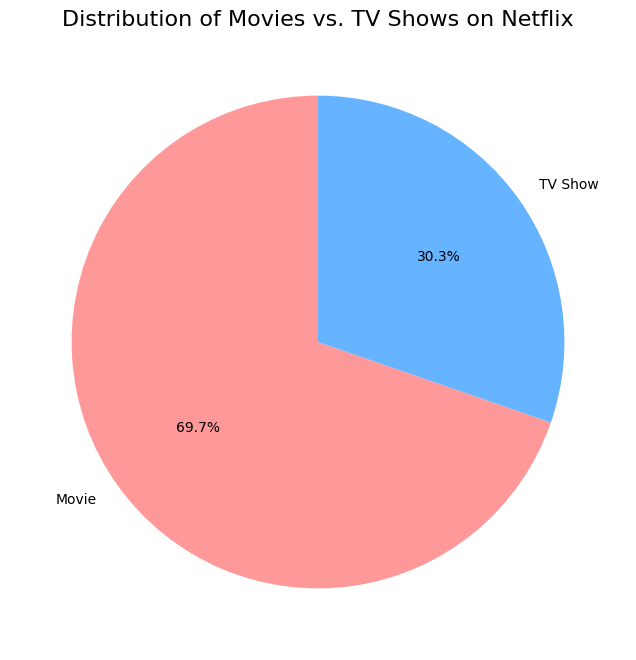

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for pie chart
content_type_distribution = df['type'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(content_type_distribution, labels=content_type_distribution.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Movies vs. TV Shows on Netflix', fontsize=16)
plt.ylabel('') # Hide the default 'y' label
plt.show()

### Bar Graph: Top 10 Countries by Content Production

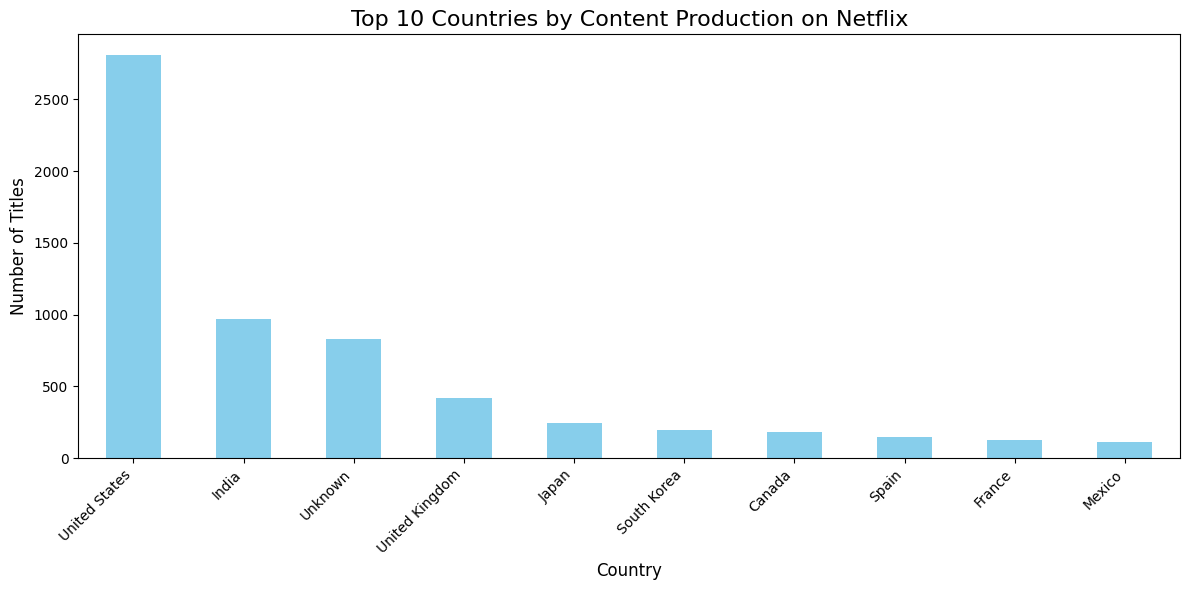

In [ ]:
# Prepare data for bar graph: Top 10 Countries
top_countries = df['country'].value_counts().head(10)

# Create the bar graph
plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Content Production on Netflix', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Heatmap: Content Added Over Time (Year vs. Month)

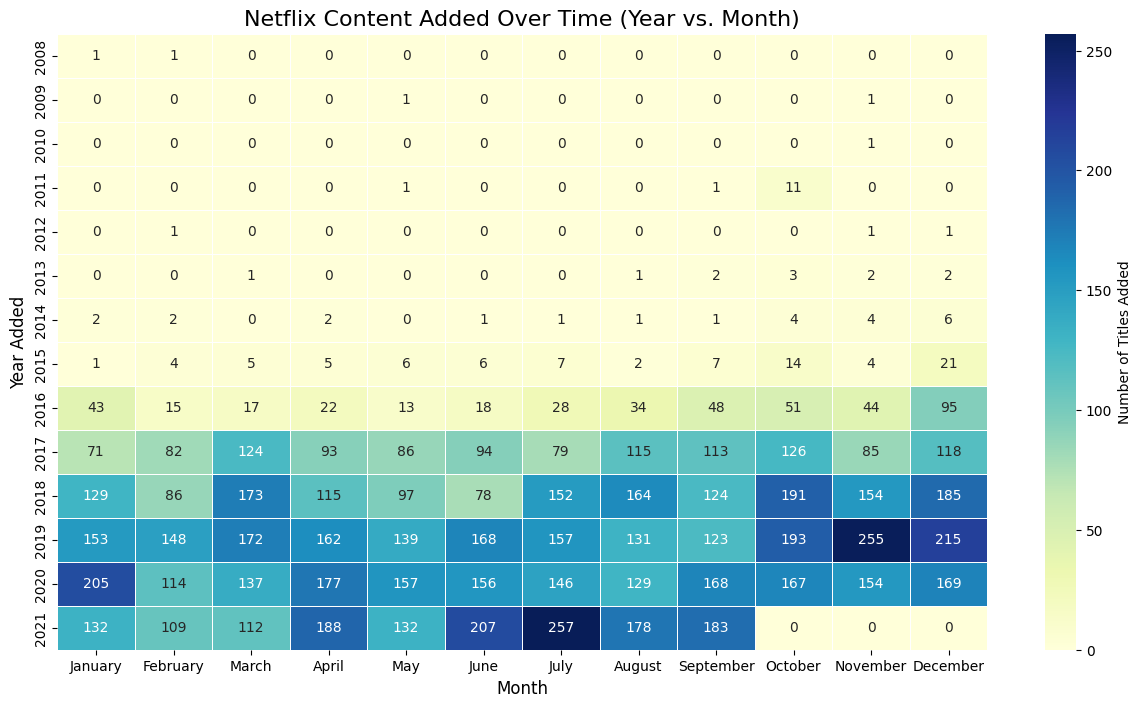

In [ ]:
import seaborn as sns

# Prepare data for heatmap: count of content added per year and month
monthly_yearly_content = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)

# Reorder months for better visualization
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_yearly_content = monthly_yearly_content[month_order]

# Create the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(monthly_yearly_content, cmap='YlGnBu', fmt='d', linewidths=.5, annot=True, cbar_kws={'label': 'Number of Titles Added'})
plt.title('Netflix Content Added Over Time (Year vs. Month)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year Added', fontsize=12)
plt.show()

## Consolidated Netflix Content Dashboard

This section presents a consolidated dashboard, combining key visualizations into a single figure to provide a comprehensive overview of the Netflix content dataset. The dashboard includes:

*   **Distribution of Movies vs. TV Shows:** A pie chart showing the proportion of each content type.
*   **Top 10 Countries by Content Production:** A bar chart highlighting the countries that produce the most content.
*   **Netflix Content Added Over Time:** A heatmap illustrating the trends of content additions across years and months.
*   **Top 10 Genres/Categories:** A bar chart showing the most common genres found in the dataset.

## Comprehensive Netflix Content Dashboard

This dashboard brings together various visualizations, including KPI cards, pie charts, bar charts, line charts, a histogram, a heatmap, and a treemap, to provide a holistic view of the Netflix content data. It's designed to be a single, professional-looking overview.

/tmp/ipykernel_6388/1722812830.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap


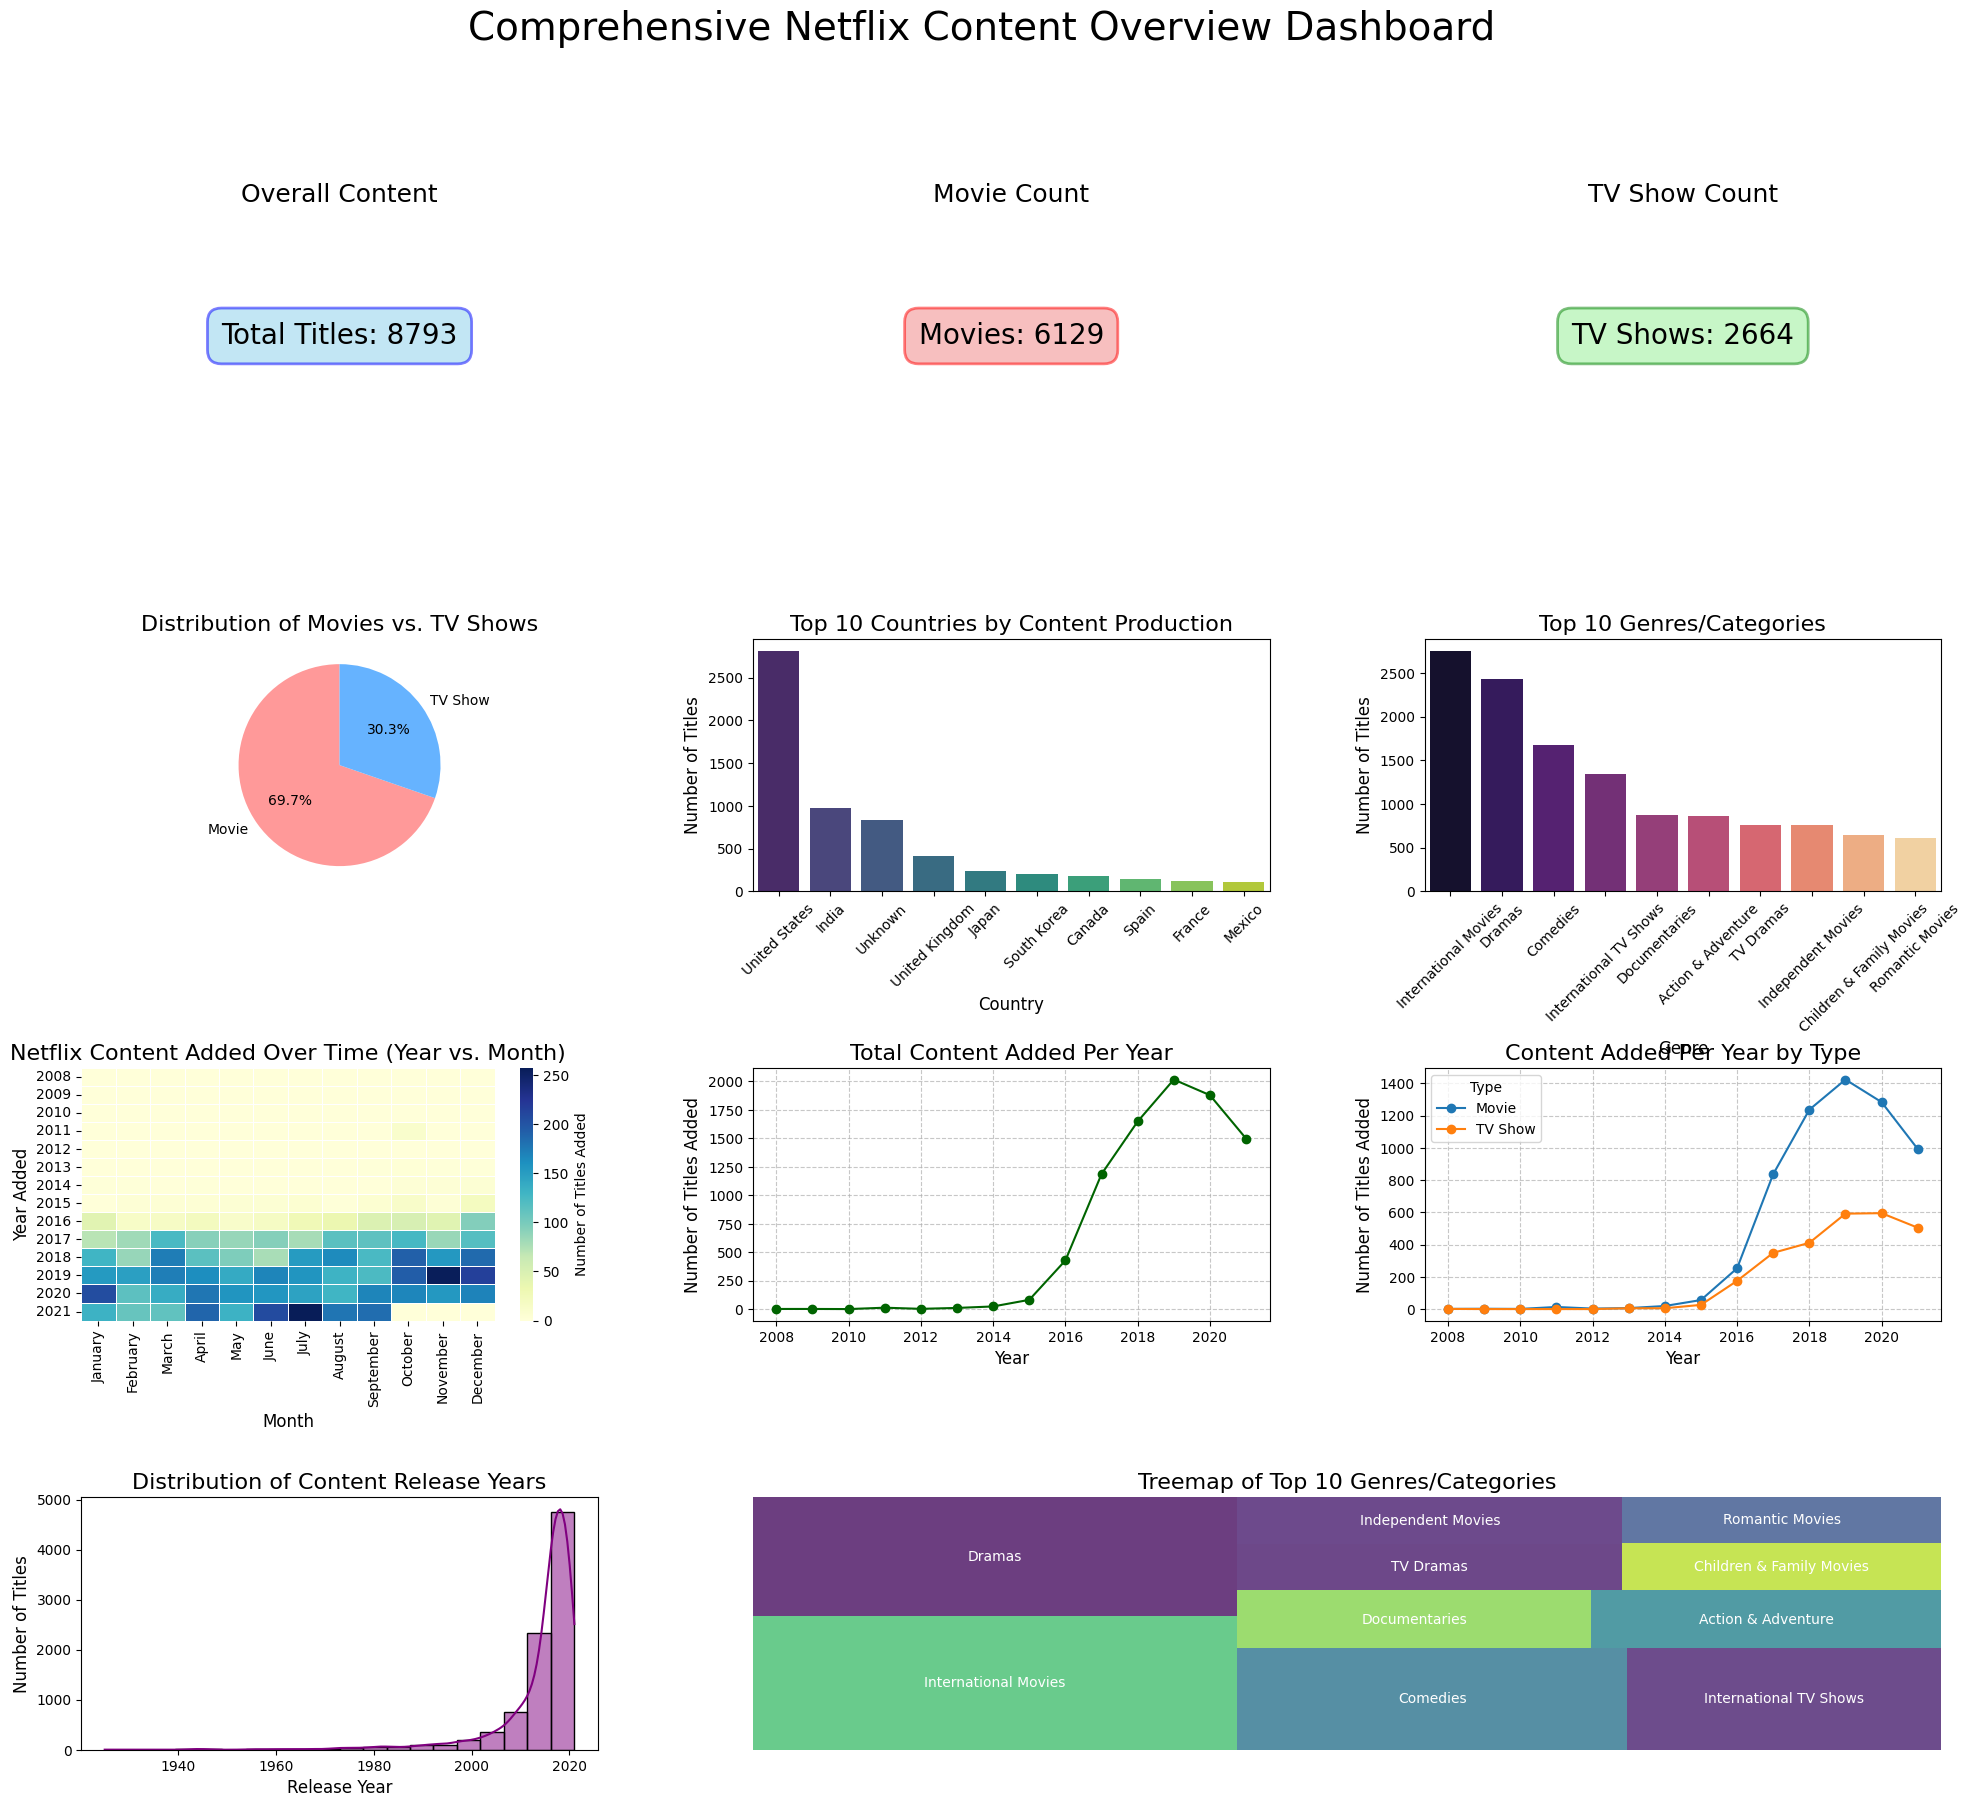

In [ ]:
!pip install squarify
import matplotlib.pyplot as plt
import seaborn as sns
import squarify # For treemap visualization

# --- Prepare Data for New Charts ---

# KPI Data (already calculated in previous steps, reusing the variables)
# total_titles, movies_count, tv_show_count are available from cell ba4a5a61

# Prepare data for Top 10 Genres (re-doing this to ensure it's fresh for the treemap)
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

# Prepare data for Line Chart: Total Content Added per Year
content_added_per_year = df['year_added'].value_counts().sort_index()

# Prepare data for Multiline Chart: Content Added per Year by Type
content_added_per_year_by_type = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# --- Create the Consolidated Dashboard Figure ---

# Set up the figure and a 3x3 grid of subplots
fig = plt.figure(figsize=(24, 20))
grid = plt.GridSpec(4, 3, wspace=0.3, hspace=0.7)

# --- Title and KPIs (Top Row) ---
fig.suptitle('Comprehensive Netflix Content Overview Dashboard', fontsize=28, y=0.98)

# KPI Card 1: Total Titles
kpi_ax1 = fig.add_subplot(grid[0, 0])
kpi_ax1.text(0.5, 0.5, f'Total Titles: {total_titles}', fontsize=20, ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.5", fc="skyblue", ec="b", lw=2, alpha=0.5))
kpi_ax1.set_title('Overall Content', fontsize=18)
kpi_ax1.axis('off')

# KPI Card 2: Movies Count
kpi_ax2 = fig.add_subplot(grid[0, 1])
kpi_ax2.text(0.5, 0.5, f'Movies: {movies_count}', fontsize=20, ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.5", fc="lightcoral", ec="r", lw=2, alpha=0.5))
kpi_ax2.set_title('Movie Count', fontsize=18)
kpi_ax2.axis('off')

# KPI Card 3: TV Shows Count
kpi_ax3 = fig.add_subplot(grid[0, 2])
kpi_ax3.text(0.5, 0.5, f'TV Shows: {tv_show_count}', fontsize=20, ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.5", fc="lightgreen", ec="g", lw=2, alpha=0.5))
kpi_ax3.set_title('TV Show Count', fontsize=18)
kpi_ax3.axis('off')

# --- Plot 1 (Row 1, Col 0): Pie Chart (Content Type Distribution) ---
ax1 = fig.add_subplot(grid[1, 0])
content_type_distribution = df['type'].value_counts()
ax1.pie(content_type_distribution, labels=content_type_distribution.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
ax1.set_title('Distribution of Movies vs. TV Shows', fontsize=16)
ax1.set_ylabel('')

# --- Plot 2 (Row 1, Col 1): Bar Graph (Top 10 Countries) ---
ax2 = fig.add_subplot(grid[1, 1])
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis', ax=ax2, hue=top_countries.index, legend=False)
ax2.set_title('Top 10 Countries by Content Production', fontsize=16)
ax2.set_xlabel('Country', fontsize=12)
ax2.set_ylabel('Number of Titles', fontsize=12)
ax2.tick_params(axis='x', rotation=45) # Removed ha='right'

# --- Plot 3 (Row 1, Col 2): Bar Graph (Top 10 Genres) ---
ax3 = fig.add_subplot(grid[1, 2])
sns.barplot(x=top_genres.index, y=top_genres.values, palette='magma', ax=ax3, hue=top_genres.index, legend=False)
ax3.set_title('Top 10 Genres/Categories', fontsize=16)
ax3.set_xlabel('Genre', fontsize=12)
ax3.set_ylabel('Number of Titles', fontsize=12)
ax3.tick_params(axis='x', rotation=45) # Removed ha='right'

# --- Plot 4 (Row 2, Col 0): Heatmap (Content Added Over Time) ---
ax4 = fig.add_subplot(grid[2, 0])
monthly_yearly_content = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_yearly_content = monthly_yearly_content.reindex(columns=month_order, fill_value=0)
sns.heatmap(monthly_yearly_content, cmap='YlGnBu', fmt='d', linewidths=.5, annot=False, cbar_kws={'label': 'Number of Titles Added'}, ax=ax4)
ax4.set_title('Netflix Content Added Over Time (Year vs. Month)', fontsize=16)
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Year Added', fontsize=12)

# --- Plot 5 (Row 2, Col 1): Line Chart (Total Content Added per Year) ---
ax5 = fig.add_subplot(grid[2, 1])
content_added_per_year.plot(kind='line', marker='o', ax=ax5, color='darkgreen')
ax5.set_title('Total Content Added Per Year', fontsize=16)
ax5.set_xlabel('Year', fontsize=12)
ax5.set_ylabel('Number of Titles Added', fontsize=12)
ax5.grid(True, linestyle='--', alpha=0.7)

# --- Plot 6 (Row 2, Col 2): Multiline Chart (Content Added per Year by Type) ---
ax6 = fig.add_subplot(grid[2, 2])
content_added_per_year_by_type.plot(kind='line', marker='o', ax=ax6)
ax6.set_title('Content Added Per Year by Type', fontsize=16)
ax6.set_xlabel('Year', fontsize=12)
ax6.set_ylabel('Number of Titles Added', fontsize=12)
ax6.legend(title='Type')
ax6.grid(True, linestyle='--', alpha=0.7)

# --- Plot 7 (Row 3, Col 0): Histogram (Distribution of Release Years) ---
ax7 = fig.add_subplot(grid[3, 0])
sns.histplot(df['release_year'], bins=20, kde=True, ax=ax7, color='purple')
ax7.set_title('Distribution of Content Release Years', fontsize=16)
ax7.set_xlabel('Release Year', fontsize=12)
ax7.set_ylabel('Number of Titles', fontsize=12)

# --- Plot 8 (Row 3, Col 1 & 2): Treemap (Top Genres) ---
ax8 = fig.add_subplot(grid[3, 1:]) # Span two columns
squarify.plot(sizes=top_genres.values, label=top_genres.index, alpha=0.8, ax=ax8,
              text_kwargs={'fontsize':10, 'color':'white'})
ax8.set_title('Treemap of Top 10 Genres/Categories', fontsize=16)
ax8.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()